## Setup


In [1]:
%matplotlib inline

from pathlib import Path
import gzip
import io
import os
# bedtools must be on PATH (conda/mamba: `conda install -c bioconda bedtools`).
# Set BEDTOOLS_BIN to prepend a specific directory instead.
_bt = os.environ.get("BEDTOOLS_BIN")
if _bt:
    os.environ["PATH"] = _bt + os.pathsep + os.environ["PATH"]
import subprocess
print(subprocess.run(["bedtools", "--version"], capture_output=True, text=True).stdout)

import re
import xml.etree.ElementTree as ET
from urllib.parse import parse_qs, urlparse

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import pybedtools
if _bt:
    pybedtools.helpers.set_bedtools_path(_bt)
import requests
import seaborn as sns
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
from tqdm import tqdm  

pd.options.mode.chained_assignment = None

matplotlib.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": [8, 6],
    "image.cmap": "Spectral_r",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.bottom": True,
    "axes.spines.top": True,
    "axes.spines.left": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.2,
    "font.size": 11,
})

PROJECT_DIR = Path.cwd()
FIG_DIR = PROJECT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


bedtools v2.31.1



In [2]:
BASE_DIR = "https://roadmapepigenomics.s3.us-west-2.amazonaws.com/index.html?prefix=hg19/uniformly_processed/data/byFileType/chromhmmSegmentations/ChmmModels/coreMarks/jointModel/final/"
METADATA_INDEX_URL = "https://roadmapepigenomics.s3.us-west-2.amazonaws.com/index.html?prefix=hg19/uniformly_processed/data/byFileType/metadata/EID_metadata.tab"

POLYCOMB_STATES = {"ReprPCWk", "ReprPC", "EnhBiv", "TssBiv", "BivFlnk"}
EXCLUDE_CHROMS = {"chrX", "chrY", "chrM"}
MERGE_IF_ADJACENT_ONLY = True
MIN_DOMAIN_BP = 1_000
N_BIOSAMPLES = 127
REFERENCE_SAMPLE_ID = "E123"  # K562 in the Roadmap metadata
GENOME_SIZE_BP = 3.2e9


## Public Roadmap ChromHMM files


In [3]:
def _parse_s3_prefix(index_url: str) -> tuple[str, str]:
    """
    Returns (bucket_base, prefix) from either:
      - https://...s3.../index.html?prefix=...
      - https://...s3.../<prefix>/  (direct "folder" URL)
    """
    u = urlparse(index_url)
    bucket_base = f"{u.scheme}://{u.netloc}/"

    qs = parse_qs(u.query)
    if "prefix" in qs and qs["prefix"]:
        prefix = qs["prefix"][0]
    else:
        # Treat path as the prefix (strip leading '/')
        prefix = u.path.lstrip("/")

    # S3 prefixes are typically normalized to end with '/'
    if prefix and not prefix.endswith("/"):
        prefix += "/"

    return bucket_base, prefix


def list_bedgz_files(
    index_url: str,
    suffix: str = "hg38lift_mnemonics.bed.gz",
    # suffix: str = "coreMarks_mnemonics.bed.gz",
    sample_id_regex: str = r"^(E\d{3})_",   # Roadmap epigenome IDs like E001_
    timeout: int = 60,
) -> pd.DataFrame:
    """
    List files under a Roadmap S3 prefix by calling S3 ListObjectsV2 (anonymous/public bucket).

    Parameters
    ----------
    index_url : str
        e.g. Roadmap "index.html?prefix=..." URL or a direct S3 prefix URL.
    suffix : str
        Only keep keys that end with this suffix.
    sample_id_regex : str
        Regex (with one capturing group) to extract sample_id from filename.
    """
    bucket_base, prefix = _parse_s3_prefix(index_url)

    keys: list[str] = []
    token: str | None = None

    # ListObjectsV2 endpoint: ?list-type=2&prefix=...&continuation-token=...
    while True:
        params = {"list-type": "2", "prefix": prefix}
        if token:
            params["continuation-token"] = token

        r = requests.get(bucket_base, params=params, timeout=timeout)
        r.raise_for_status()

        # S3 XML has a default namespace; strip it for easy parsing
        root = ET.fromstring(r.text)

        def _strip_ns(tag: str) -> str:
            return tag.split("}", 1)[-1] if "}" in tag else tag

        # Collect <Contents><Key>...</Key></Contents>
        for contents in root.iter():
            if _strip_ns(contents.tag) == "Contents":
                key_el = None
                for child in list(contents):
                    if _strip_ns(child.tag) == "Key":
                        key_el = child
                        break
                if key_el is not None and key_el.text:
                    keys.append(key_el.text)

        # Pagination
        is_truncated = False
        next_token = None
        for el in root.iter():
            t = _strip_ns(el.tag)
            if t == "IsTruncated" and (el.text or "").lower() == "true":
                is_truncated = True
            if t == "NextContinuationToken":
                next_token = el.text

        if not is_truncated:
            break
        token = next_token
        if not token:
            # Defensive: truncated but no token — avoid infinite loop
            break

    # Filter down to desired files
    keys = sorted(set(k for k in keys if k.endswith(suffix)))

    df = pd.DataFrame({"key": keys})
    df["filename"] = df["key"].str.rsplit("/", n=1).str[-1]
    df["url"] = bucket_base + df["key"]
    df["sample_id"] = df["filename"].str.extract(sample_id_regex, expand=False)

    # Keep only rows where we found a sample_id (optional; comment out if undesired)
    # df = df[df["sample_id"].notna()].reset_index(drop=True)

    return df[["sample_id", "filename", "url", "key"]]


files_df = list_bedgz_files(BASE_DIR)
print(files_df.head())
print("n_files =", len(files_df))


  sample_id                                     filename  \
0      E001  E001_15_coreMarks_hg38lift_mnemonics.bed.gz   
1      E002  E002_15_coreMarks_hg38lift_mnemonics.bed.gz   
2      E003  E003_15_coreMarks_hg38lift_mnemonics.bed.gz   
3      E004  E004_15_coreMarks_hg38lift_mnemonics.bed.gz   
4      E005  E005_15_coreMarks_hg38lift_mnemonics.bed.gz   

                                                 url  \
0  https://roadmapepigenomics.s3.us-west-2.amazon...   
1  https://roadmapepigenomics.s3.us-west-2.amazon...   
2  https://roadmapepigenomics.s3.us-west-2.amazon...   
3  https://roadmapepigenomics.s3.us-west-2.amazon...   
4  https://roadmapepigenomics.s3.us-west-2.amazon...   

                                                 key  
0  hg19/uniformly_processed/data/byFileType/chrom...  
1  hg19/uniformly_processed/data/byFileType/chrom...  
2  hg19/uniformly_processed/data/byFileType/chrom...  
3  hg19/uniformly_processed/data/byFileType/chrom...  
4  hg19/uniformly_processed

In [4]:
def read_chromhmm_bed9_gz(url: str) -> pd.DataFrame:
    """
    Read a remote .bed.gz (BED9) into a DataFrame with columns:
    chrom, start, end, state
    """
    # Stream download -> pandas can read gz directly from bytes via gzip wrapper
    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()

    # Load into memory once (files are a few MB). If you want fully-streaming, say so.
    raw = r.content
    with gzip.GzipFile(fileobj=io.BytesIO(raw)) as gz:
        df = pd.read_csv(
            gz,
            sep="\t",
            header=None,
            usecols=[0, 1, 2, 3],
            names=["chrom", "start", "end", "state"],
            dtype={"chrom": "string", "start": np.int64, "end": np.int64, "state": "string"},
        )
    return df


## Domain caller


In [5]:
def call_polycomb_domains(
    seg: pd.DataFrame,
    polycomb_states = {"ReprPCWk", "ReprPC", "EnhBiv", "TssBiv","BivFlnk"},
    adjacent_only: bool = True,
    max_merge_gap_bp: int = 199,
    min_domain_bp: int = 1000,
    min_reprpc_frac: float = 0,
    reprpc_state: str = "ReprPC",
    require_reprpc_edges: bool = False,
    exclude_chroms: set[str] | None = {"chrX", "chrY", "chrM"},
) -> pd.DataFrame:
    """
    Calls polycomb domains from ChromHMM segments.

    Supports:
      - input columns already normalized: chrom, start, end, state
      - Roadmap-style inputs with extra index column and/or unnamed columns

    polycomb_states can be either:
      - mnemonics (e.g. {"ReprPC", "Biv"})
      - full labels (e.g. {"16_ReprPC", "17_ReprPCWk"})
    """

    def _normalize_seg(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        if {"chrom", "start", "end", "state"}.issubset(df.columns):
            out = df[["chrom", "start", "end", "state"]].copy()
        else:
            cols = list(df.columns)
            s_as_str = {c: df[c].astype("string").fillna(pd.NA) for c in cols}

            def chr_score(c):
                v = s_as_str[c].fillna("")
                return (v.str.startswith("chr")).mean()

            def state_score(c):
                v = s_as_str[c].fillna("")
                has_us = (v.str.contains("_")).mean()
                looks_like_state = (v.str.contains("ReprPC|Biv|Tss", regex=True)).mean()
                return max(has_us, looks_like_state)

            chrom_col = max(cols, key=chr_score)
            state_col = max([c for c in cols if c != chrom_col], key=state_score)

            num_ok = {}
            num_vals = {}
            for c in cols:
                if c in (chrom_col, state_col):
                    continue
                x = pd.to_numeric(df[c], errors="coerce")
                num_vals[c] = x
                num_ok[c] = x.notna().mean()

            num_cands = [c for c in num_ok if num_ok[c] > 0.9]
            if len(num_cands) < 2:
                raise ValueError("Could not infer start and end columns from seg")

            best_pair = None
            best_score = -1
            for a in num_cands:
                for b in num_cands:
                    if a == b:
                        continue
                    x = num_vals[a]
                    y = num_vals[b]
                    ok = (x.notna() & y.notna())
                    if ok.sum() == 0:
                        continue
                    score = (x[ok] < y[ok]).mean()
                    if score > best_score:
                        best_score = score
                        best_pair = (a, b)

            if best_pair is None or best_score < 0.9:
                raise ValueError("Could not infer a reliable start/end column pair")

            start_col, end_col = best_pair

            out = pd.DataFrame(
                {
                    "chrom": s_as_str[chrom_col],
                    "start": pd.to_numeric(df[start_col], errors="coerce").astype("int64"),
                    "end": pd.to_numeric(df[end_col], errors="coerce").astype("int64"),
                    "state": s_as_str[state_col],
                }
            )

        out = out.dropna(subset=["chrom", "start", "end", "state"]).copy()
        out["chrom"] = out["chrom"].astype("string")
        out["state"] = out["state"].astype("string")
        return out

    if exclude_chroms is None:
        exclude_chroms = set()

    seg = _normalize_seg(seg)

    # Exclude chromosomes early
    seg = seg[~seg["chrom"].isin(exclude_chroms)].copy()

    # Build mnemonic column: "16_ReprPC" -> "ReprPC"
    seg["state_mnemonic"] = seg["state"].str.split("_", n=1).str[-1]

    polycomb_states = set(polycomb_states)
    user_uses_full = any("_" in s for s in polycomb_states)

    if user_uses_full:
        seg["state_key"] = seg["state"]
        states = sorted(polycomb_states)
        reprpc_key = reprpc_state
    else:
        seg["state_key"] = seg["state_mnemonic"]
        states = sorted(polycomb_states)
        reprpc_key = reprpc_state.split("_", 1)[-1]

    if reprpc_key not in polycomb_states:
        raise ValueError(f"reprpc_state='{reprpc_state}' must correspond to an entry in polycomb_states")

    cols = ["chrom", "start", "end", "length_bp", "distance_to_next_bp", "n_segments"]
    cols += [f"bp_{s}" for s in states] + [f"frac_{s}" for s in states]

    df = seg[seg["state_key"].isin(polycomb_states)].copy()
    if df.empty:
        return pd.DataFrame(columns=cols)

    df = df.sort_values(["chrom", "start", "end"], kind="mergesort").reset_index(drop=True)
    df["seg_len"] = df["end"] - df["start"]

    # Define preliminary merged domains with optional gap bridging
    df["prev_end"] = df.groupby("chrom")["end"].shift(1)
    df["gap_bp"] = df["start"] - df["prev_end"]

    max_merge_gap_bp = int(max_merge_gap_bp)

    if adjacent_only and max_merge_gap_bp <= 0:
        # Original strict adjacency
        new_domain = df["prev_end"].isna() | (df["start"] != df["prev_end"])
    else:
        # Merge if gap_bp <= max_merge_gap_bp (this includes overlaps where gap_bp < 0)
        new_domain = df["prev_end"].isna() | (df["gap_bp"] > max_merge_gap_bp)

    df["domain_id"] = new_domain.groupby(df["chrom"]).cumsum()

    # Preliminary edges (before optional ReprPC truncation)
    prelim_edges = (
        df.groupby(["chrom", "domain_id"], as_index=False)
          .agg(start=("start", "min"), end=("end", "max"))
    )

    # Optionally truncate each preliminary domain to ReprPC bounds
    # Domains with no ReprPC are retained unchanged.
    if require_reprpc_edges:
        reprpc_bounds = (
            df.loc[df["state_key"] == reprpc_key]
              .groupby(["chrom", "domain_id"], as_index=False)
              .agg(reprpc_start=("start", "min"), reprpc_end=("end", "max"))
        )

        domain_edges = prelim_edges.merge(reprpc_bounds, on=["chrom", "domain_id"], how="left")
        domain_edges["start"] = domain_edges["reprpc_start"].fillna(domain_edges["start"])
        domain_edges["end"] = domain_edges["reprpc_end"].fillna(domain_edges["end"])

        df = df.merge(
            domain_edges[["chrom", "domain_id", "reprpc_start", "reprpc_end"]],
            on=["chrom", "domain_id"],
            how="left",
        )
        has_bounds = df["reprpc_start"].notna()
        df = df.loc[
            ~has_bounds
            | ((df["start"] >= df["reprpc_start"]) & (df["end"] <= df["reprpc_end"]))
        ].copy()

        df = df.drop(columns=["reprpc_start", "reprpc_end"])
        domain_edges = domain_edges.drop(columns=["reprpc_start", "reprpc_end"])
    else:
        domain_edges = prelim_edges

    if df.empty:
        return pd.DataFrame(columns=cols)

    # Composition within domains
    comp = (
        df.pivot_table(
            index=["chrom", "domain_id"],
            columns="state_key",
            values="seg_len",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(columns=states, fill_value=0)
        .reset_index()
        .rename(columns={s: f"bp_{s}" for s in states})
    )

    nseg = df.groupby(["chrom", "domain_id"], as_index=False).agg(n_segments=("state_key", "size"))

    domains = (
        domain_edges.merge(nseg, on=["chrom", "domain_id"], how="inner")
                   .merge(comp, on=["chrom", "domain_id"], how="inner")
    )

    domains["length_bp"] = domains["end"] - domains["start"]

    domains = domains.loc[domains["length_bp"] >= int(min_domain_bp)].copy()
    if domains.empty:
        return pd.DataFrame(columns=cols)

    for s in states:
        domains[f"frac_{s}"] = domains[f"bp_{s}"] / domains["length_bp"]

    # Include domains with zero ReprPC when min_reprpc_frac == 0
    domains = domains.loc[domains[f"frac_{reprpc_key}"] >= float(min_reprpc_frac)].copy()
    if domains.empty:
        return pd.DataFrame(columns=cols)

    domains = domains.sort_values(["chrom", "start", "end"], kind="mergesort").reset_index(drop=True)
    domains["next_start"] = domains.groupby("chrom")["start"].shift(-1)
    domains["distance_to_next_bp"] = domains["next_start"] - domains["end"]
    domains.loc[domains["next_start"].isna(), "distance_to_next_bp"] = np.nan

    domains = domains.drop(columns=["next_start", "domain_id"])

    return domains[cols]


## K562 sanity check


In [6]:
sample_row = files_df.loc[files_df["sample_id"] == REFERENCE_SAMPLE_ID].iloc[0]
seg = read_chromhmm_bed9_gz(sample_row.url)
example_domains = call_polycomb_domains(
    seg,
    polycomb_states=POLYCOMB_STATES,
    adjacent_only=MERGE_IF_ADJACENT_ONLY,
    min_domain_bp=MIN_DOMAIN_BP,
    exclude_chroms=EXCLUDE_CHROMS,
)
# 260803_WT_timeseries_clean_chromHMM_pub.ipynb reads this from data/2024/ENCODE_states/
_states_dir = PROJECT_DIR / "data" / "2024" / "ENCODE_states"
_states_dir.mkdir(parents=True, exist_ok=True)
example_domains[["chrom", "start", "end"]].to_csv(
    _states_dir / "K562_E123_15_coreMarks_domains.bed",
    sep="	",
    header=False,
    index=False,
)
example_domains["length_bp"].describe()


count     17827.000000
mean      20926.141078
std       24954.303398
min        1000.000000
25%        5800.000000
50%       12400.000000
75%       26400.000000
max      357200.000000
Name: length_bp, dtype: float64

## Biosample metadata


In [7]:
def index_url_to_s3_object_url(index_url: str) -> str:
    u = urlparse(index_url)
    bucket_base = f"{u.scheme}://{u.netloc}/"
    qs = parse_qs(u.query)
    if "prefix" not in qs or not qs["prefix"]:
        raise ValueError("Expected an index.html?prefix=... URL")
    key = qs["prefix"][0].lstrip("/")
    return bucket_base + key

meta = pd.read_csv(
    index_url_to_s3_object_url(METADATA_INDEX_URL),
    sep="	",
    header=0,
    dtype="string",
    keep_default_na=False,
)
meta.head()


,EID,GROUP,COLOR,MNEMONIC,STD_NAME,EDACC_NAME,ANATOMY,TYPE,AGE,SEX,SOLID_LIQUID,ETHNICITY,SINGLEDONOR_COMPOSITE
0,E001,ESC,#924965,ESC.I3,ES-I3 Cells,ES-I3_Cell_Line,ESC,PrimaryCulture,CL,Female,NA,NA,SD
1,E002,ESC,#924965,ESC.WA7,ES-WA7 Cells,ES-WA7_Cell_Line,ESC,PrimaryCulture,CL,Female,NA,NA,SD
2,E003,ESC,#924965,ESC.H1,H1 Cells,H1_Cell_Line,ESC,PrimaryCulture,CL,Male,NA,NA,SD
3,E004,ES-deriv,#4178AE,ESDR.H1.BMP4.MESO,H1 BMP4 Derived Mesendoderm Cultured Cells,H1_BMP4_Derived_Mesendoderm_Cultured_Cells,ESC_DERIVED,ESCDerived,CL,Male,NA,NA,SD
4,E005,ES-deriv,#4178AE,ESDR.H1.BMP4.TROP,H1 BMP4 Derived Trophoblast Cultured Cells,H1_BMP4_Derived_Trophoblast_Cultured_Cells,ESC_DERIVED,ESCDerived,CL,Male,NA,NA,SD


## Process all biosamples


In [8]:
def process_all(files_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    domains_list = []
    summaries = []
    states = sorted(POLYCOMB_STATES)

    for row in tqdm(files_df.itertuples(index=False), total=len(files_df)):
        seg = read_chromhmm_bed9_gz(row.url)
        dom = call_polycomb_domains(
            seg,
            polycomb_states=POLYCOMB_STATES,
            adjacent_only=MERGE_IF_ADJACENT_ONLY,
            min_domain_bp=MIN_DOMAIN_BP,
            exclude_chroms=EXCLUDE_CHROMS,
        )

        dom.insert(0, "sample_id", row.sample_id)
        dom.insert(1, "filename", row.filename)
        domains_list.append(dom)

        total_bp = float(dom["length_bp"].sum()) if len(dom) else 0.0
        n_domains = int(len(dom))
        summary = {
            "sample_id": row.sample_id,
            "filename": row.filename,
            "n_domains": n_domains,
            "polycomb_coverage_bp": total_bp,
            "polycomb_coverage_mb": total_bp / 1e6,
            "polycomb_coverage_per": total_bp / GENOME_SIZE_BP * 100,
            "median_domain_bp": float(dom["length_bp"].median()) if n_domains else np.nan,
            "mean_domain_bp": float(dom["length_bp"].mean()) if n_domains else np.nan,
            "p95_domain_bp": float(dom["length_bp"].quantile(0.95)) if n_domains else np.nan,
        }

        for s in states:
            bp_col = f"bp_{s}"
            summary[f"frac_bp_{s}"] = float(dom[bp_col].sum()) / total_bp if total_bp > 0 else np.nan
            summary[f"frac_domains_with_{s}"] = float((dom[bp_col] > 0).mean()) if n_domains else np.nan

        summaries.append(summary)

    all_domains = pd.concat(domains_list, ignore_index=True) if domains_list else pd.DataFrame()
    coverage_tbl = (
        pd.DataFrame(summaries)
        .sort_values("polycomb_coverage_bp", ascending=False)
        .reset_index(drop=True)
    )
    return all_domains, coverage_tbl

files_df = list_bedgz_files(BASE_DIR)
analysis_files = files_df.head(N_BIOSAMPLES).copy()
all_domains, coverage_tbl = process_all(analysis_files)
coverage_tbl.head()


100%|██████████| 127/127 [03:24<00:00,  1.61s/it]


,sample_id,filename,n_domains,polycomb_coverage_bp,polycomb_coverage_mb,polycomb_coverage_per,median_domain_bp,mean_domain_bp,p95_domain_bp,frac_bp_BivFlnk,frac_domains_with_BivFlnk,frac_bp_EnhBiv,frac_domains_with_EnhBiv,frac_bp_ReprPC,frac_domains_with_ReprPC,frac_bp_ReprPCWk,frac_domains_with_ReprPCWk,frac_bp_TssBiv,frac_domains_with_TssBiv
0,E034,E034_15_coreMarks_hg38lift_mnemonics.bed.gz,27533,804340488.0,804.340488,25.135640,14000.0,29213.688592,108400.0,0.005389,0.171649,0.018418,0.344096,0.114302,0.510151,0.861088,0.983402,0.000754,0.047870
1,E080,E080_15_coreMarks_hg38lift_mnemonics.bed.gz,34971,615312421.0,615.312421,19.228513,10000.0,17594.933545,59800.0,0.010506,0.172572,0.030292,0.331189,0.201013,0.552143,0.754604,0.957908,0.003530,0.089874
2,E121,E121_15_coreMarks_hg38lift_mnemonics.bed.gz,26299,614786058.0,614.786058,19.212064,13600.0,23376.784593,77800.0,0.000333,0.026731,0.002219,0.107495,0.114969,0.486330,0.879867,0.998327,0.002568,0.075630
3,E109,E109_15_coreMarks_hg38lift_mnemonics.bed.gz,22458,560830906.0,560.830906,17.525966,12400.0,24972.433253,91000.0,0.000203,0.018657,0.002749,0.116351,0.041512,0.248286,0.953141,0.998174,0.002333,0.071823
4,E118,E118_15_coreMarks_hg38lift_mnemonics.bed.gz,31486,548096136.0,548.096136,17.128004,8400.0,17407.614051,65400.0,0.011567,0.265229,0.022188,0.322270,0.175046,0.440291,0.773213,0.843105,0.017931,0.265928


## Jaccard similarity between domain sets

Jaccard similarity is computed from base-pair interval overlap as `intersection_bp / union_bp`. This section uses `pybedtools.BedTool.jaccard`, which wraps `bedtools jaccard`; domains are converted to sorted BED intervals before pairwise comparison. A value of 1 means two biosamples have identical domain intervals, and a value of 0 means they have no overlapping domain bases.


In [9]:
def _bed_dataframe(domains: pd.DataFrame) -> pd.DataFrame:
    bed = domains.loc[:, ["chrom", "start", "end"]].copy()
    bed["chrom"] = bed["chrom"].astype(str)
    bed["start"] = bed["start"].astype(np.int64)
    bed["end"] = bed["end"].astype(np.int64)
    return bed.sort_values(["chrom", "start", "end"], kind="mergesort").reset_index(drop=True)


def _make_bedtool(domains: pd.DataFrame) -> pybedtools.BedTool:
    return pybedtools.BedTool.from_dataframe(_bed_dataframe(domains))


def domain_jaccard_similarity(a_bedtool: pybedtools.BedTool, b_bedtool: pybedtools.BedTool) -> float:
    stats = a_bedtool.jaccard(b=b_bedtool)
    return float(stats["jaccard"])


def pairwise_domain_jaccard_similarity(
    all_domains: pd.DataFrame,
    sample_col: str = "sample_id",
) -> pd.DataFrame:
    domains = all_domains.copy()
    domains[sample_col] = domains[sample_col].astype(str)
    samples = sorted(domains[sample_col].dropna().unique())
    bedtools_by_sample = {
        sample: _make_bedtool(domains.loc[domains[sample_col] == sample, ["chrom", "start", "end"]])
        for sample in samples
    }

    matrix = pd.DataFrame(np.nan, index=samples, columns=samples, dtype=float)
    for i, sample_a in enumerate(tqdm(samples, desc="Jaccard similarity")):
        matrix.iat[i, i] = 1.0
        for j in range(i + 1, len(samples)):
            sample_b = samples[j]
            similarity = domain_jaccard_similarity(bedtools_by_sample[sample_a], bedtools_by_sample[sample_b])
            matrix.iat[i, j] = similarity
            matrix.iat[j, i] = similarity
    return matrix


def add_jaccard_summary(
    coverage_tbl: pd.DataFrame,
    jaccard_similarity: pd.DataFrame,
    reference_sample_id: str | None = None,
) -> pd.DataFrame:
    out = coverage_tbl.copy()
    sample_ids = out["sample_id"].astype(str)

    off_diagonal = jaccard_similarity.copy()
    np.fill_diagonal(off_diagonal.values, np.nan)

    out["mean_jaccard_similarity"] = sample_ids.map(off_diagonal.mean(axis=1))
    out["median_jaccard_similarity"] = sample_ids.map(off_diagonal.median(axis=1))
    out["most_similar_sample_id"] = sample_ids.map(off_diagonal.idxmax(axis=1))
    out["most_similar_jaccard_similarity"] = sample_ids.map(off_diagonal.max(axis=1))

    if reference_sample_id in jaccard_similarity.index:
        out[f"jaccard_similarity_to_{reference_sample_id}"] = sample_ids.map(jaccard_similarity[reference_sample_id])

    return out

jaccard_similarity = pairwise_domain_jaccard_similarity(all_domains)
coverage_tbl = add_jaccard_summary(coverage_tbl, jaccard_similarity, REFERENCE_SAMPLE_ID)
coverage_tbl.sort_values("mean_jaccard_similarity", ascending=False).head()


Jaccard similarity: 100%|██████████| 127/127 [03:49<00:00,  1.80s/it]


,sample_id,filename,n_domains,polycomb_coverage_bp,polycomb_coverage_mb,polycomb_coverage_per,median_domain_bp,mean_domain_bp,p95_domain_bp,frac_bp_BivFlnk,...,frac_domains_with_ReprPC,frac_bp_ReprPCWk,frac_domains_with_ReprPCWk,frac_bp_TssBiv,frac_domains_with_TssBiv,mean_jaccard_similarity,median_jaccard_similarity,most_similar_sample_id,most_similar_jaccard_similarity,jaccard_similarity_to_E123
40,E090,E090_15_coreMarks_hg38lift_mnemonics.bed.gz,26099,355403376.0,355.403376,11.106355,7600.0,13617.509330,45600.0,0.016985,...,0.407908,0.793045,0.945783,0.005991,0.113644,0.289754,0.293805,E089,0.566133,0.290020
31,E107,E107_15_coreMarks_hg38lift_mnemonics.bed.gz,20902,380076996.0,380.076996,11.877406,9600.0,18183.762128,63600.0,0.014810,...,0.506650,0.760363,0.965266,0.007355,0.172711,0.285287,0.291936,E108,0.581230,0.302477
36,E092,E092_15_coreMarks_hg38lift_mnemonics.bed.gz,24283,363405818.0,363.405818,11.356432,8200.0,14965.441585,50800.0,0.013923,...,0.523453,0.744813,0.929333,0.011673,0.184079,0.282907,0.285886,E089,0.567438,0.298840
57,E108,E108_15_coreMarks_hg38lift_mnemonics.bed.gz,17149,293736545.0,293.736545,9.179267,9600.0,17128.494081,59000.0,0.012267,...,0.441892,0.827546,0.981981,0.007559,0.170739,0.282684,0.295015,E107,0.581230,0.270975
63,E077,E077_15_coreMarks_hg38lift_mnemonics.bed.gz,17704,273611147.0,273.611147,8.550348,8800.0,15454.764291,51600.0,0.009319,...,0.317951,0.896559,0.981812,0.010523,0.175441,0.280386,0.284883,E101,0.464394,0.259277


In [10]:
summary_tbl = (
    coverage_tbl[coverage_tbl["sample_id"].isin(meta["EID"])]
    .merge(meta, left_on="sample_id", right_on="EID", how="left")
    .sort_values("polycomb_coverage_bp", ascending=False)
    .reset_index(drop=True)
)

summary_tbl[[
    "sample_id",
    "MNEMONIC",
    "n_domains",
    "polycomb_coverage_per",
    "mean_jaccard_similarity",
    "median_jaccard_similarity",
    "most_similar_sample_id",
    "most_similar_jaccard_similarity",
    f"jaccard_similarity_to_{REFERENCE_SAMPLE_ID}",
]].head(10)


,sample_id,MNEMONIC,n_domains,polycomb_coverage_per,mean_jaccard_similarity,median_jaccard_similarity,most_similar_sample_id,most_similar_jaccard_similarity,jaccard_similarity_to_E123
0,E034,BLD.CD3.PPC,27533,25.135640,0.241996,0.251810,E109,0.463251,0.317873
1,E080,ADRL.GLND.FET,34971,19.228513,0.245079,0.255718,E034,0.442801,0.293761
2,E121,MUS.HSMMT,26299,19.212064,0.222651,0.219975,E120,0.478088,0.229431
3,E109,GI.S.INT,22458,17.525966,0.264740,0.284060,E034,0.463251,0.263685
4,E118,LIV.HEPG2.CNCR,31486,17.128004,0.238584,0.245599,E034,0.420898,0.327039
5,E061,SKIN.PEN.FRSK.MEL.03,23082,16.710190,0.195805,0.206371,E059,0.478397,0.175108
6,E017,LNG.IMR90,24980,16.596544,0.245993,0.234619,E129,0.543337,0.297359
7,E115,BLD.DND41.CNCR,18718,15.942675,0.203166,0.214066,E034,0.375845,0.251293
8,E049,STRM.CHON.MRW.DR.MSC,24397,14.978162,0.250362,0.249692,E026,0.686534,0.250085
9,E052,MUS.SAT,21079,14.677422,0.257106,0.246638,E129,0.558403,0.288545


In [11]:
summary_tbl[[
    "sample_id",
    "MNEMONIC",
    "n_domains",
    "polycomb_coverage_per",
    "mean_jaccard_similarity",
    "median_jaccard_similarity",
    "most_similar_sample_id",
    "most_similar_jaccard_similarity",
    f"jaccard_similarity_to_{REFERENCE_SAMPLE_ID}",
]].sort_values(by = 'most_similar_jaccard_similarity', ascending=False)


,sample_id,MNEMONIC,n_domains,polycomb_coverage_per,mean_jaccard_similarity,median_jaccard_similarity,most_similar_sample_id,most_similar_jaccard_similarity,jaccard_similarity_to_E123
19,E056,SKIN.PEN.FRSK.FIB.02,19760,13.575868,0.256662,0.239565,E055,0.697823,0.321965
11,E055,SKIN.PEN.FRSK.FIB.01,24036,14.464439,0.249046,0.233986,E056,0.697823,0.314309
8,E049,STRM.CHON.MRW.DR.MSC,24397,14.978162,0.250362,0.249692,E026,0.686534,0.250085
15,E026,STRM.MRW.MSC,20406,13.787476,0.255284,0.253639,E049,0.686534,0.257245
76,E029,BLD.CD14.PC,17343,7.588321,0.247643,0.240715,E124,0.643419,0.188294
...,...,...,...,...,...,...,...,...,...
96,E065,VAS.AOR,17920,5.335542,0.150590,0.155050,E078,0.204355,0.114155
123,E007,ESDR.H1.NEUR.PROG,6641,1.220658,0.071574,0.061801,E021,0.180589,0.035755
124,E113,SPLN,5190,0.806010,0.065604,0.060714,E076,0.137783,0.035153
125,E094,GI.STMC.GAST,3536,0.564760,0.024747,0.023149,E113,0.054966,0.013633


In [12]:
summary_tbl[summary_tbl['MNEMONIC'] == 'BLD.CD34.PC'][[
    "sample_id",
    "MNEMONIC",
    "n_domains",
    "polycomb_coverage_per",
    "mean_jaccard_similarity",
    "median_jaccard_similarity",
    "most_similar_sample_id",
    "most_similar_jaccard_similarity",
    f"jaccard_similarity_to_{REFERENCE_SAMPLE_ID}",
]]


,sample_id,MNEMONIC,n_domains,polycomb_coverage_per,mean_jaccard_similarity,median_jaccard_similarity,most_similar_sample_id,most_similar_jaccard_similarity,jaccard_similarity_to_E123
48,E035,BLD.CD34.PC,17701,10.131684,0.23695,0.230922,E033,0.556395,0.181697


In [13]:
summary_tbl[summary_tbl['MNEMONIC'].str.contains('BLD')]

,sample_id,filename,n_domains,polycomb_coverage_bp,polycomb_coverage_mb,polycomb_coverage_per,median_domain_bp,mean_domain_bp,p95_domain_bp,frac_bp_BivFlnk,...,MNEMONIC,STD_NAME,EDACC_NAME,ANATOMY,TYPE,AGE,SEX,SOLID_LIQUID,ETHNICITY,SINGLEDONOR_COMPOSITE
0,E034,E034_15_coreMarks_hg38lift_mnemonics.bed.gz,27533,804340488.0,804.340488,25.135640,14000.0,29213.688592,108400.0,0.005389,...,BLD.CD3.PPC,Primary T cells from peripheral blood,CD3_Primary_Cells_Peripheral_UW,BLOOD,PrimaryCell,"21Y, 37Y",Male,LIQUID,"Caucasian, Hispanic",C
7,E115,E115_15_coreMarks_hg38lift_mnemonics.bed.gz,18718,510165602.0,510.165602,15.942675,15000.0,27255.347900,93000.0,0.002702,...,BLD.DND41.CNCR,Dnd41 TCell Leukemia Cell Line,Dnd41_TCell_Leukemia,BLOOD,CellLine,,Male,,,SD
25,E041,E041_15_coreMarks_hg38lift_mnemonics.bed.gz,19162,393059924.0,393.059924,12.283123,11600.0,20512.468636,69200.0,0.007259,...,BLD.CD4.CD25M.IL17M.PL.TPC,Primary T helper cells PMA-I stimulated,CD4+_CD25-_IL17-_PMA-Ionomycin_stimulated_MACS...,BLOOD,PrimaryCell,Unknown,Unknown,LIQUID,Unknown,C
26,E033,E033_15_coreMarks_hg38lift_mnemonics.bed.gz,15636,389432640.0,389.432640,12.169770,12200.0,24906.155027,92650.0,0.005084,...,BLD.CD3.CPC,Primary T cells from cord blood,CD3_Primary_Cells_Cord_BI,BLOOD,PrimaryCell,Fetus (GW unknown),Unknown,LIQUID,Unknown,C
30,E031,E031_15_coreMarks_hg38lift_mnemonics.bed.gz,21642,380639992.0,380.639992,11.895000,10200.0,17588.022918,57400.0,0.004271,...,BLD.CD19.CPC,Primary B cells from cord blood,CD19_Primary_Cells_Cord_BI,BLOOD,PrimaryCell,Fetus (GW unknown),Mixed,LIQUID,Unknown,C
32,E051,E051_15_coreMarks_hg38lift_mnemonics.bed.gz,21655,374213657.0,374.213657,11.694177,10200.0,17280.704549,56600.0,0.020290,...,BLD.MOB.CD34.PC.M,Primary hematopoietic stem cells G-CSF-mobiliz...,Mobilized_CD34_Primary_Cells_Male,BLOOD,PrimaryCell,42Y,Male,LIQUID,Caucasian,SD
33,E123,E123_15_coreMarks_hg38lift_mnemonics.bed.gz,17827,373050317.0,373.050317,11.657822,12400.0,20926.141078,68400.0,0.000756,...,BLD.K562.CNCR,K562 Leukemia Cells,K562_Leukemia,BLOOD,PrimaryCulture,,Female,,,SD
41,E044,E044_15_coreMarks_hg38lift_mnemonics.bed.gz,18043,353310862.0,353.310862,11.040964,11801.0,19581.602949,62600.0,0.011246,...,BLD.CD4.CD25.CD127M.TREGPC,Primary T regulatory cells from peripheral blood,CD4+_CD25+_CD127-_Treg_Primary_Cells,BLOOD,PrimaryCell,Unknown,Unknown,LIQUID,Unknown,C
43,E036,E036_15_coreMarks_hg38lift_mnemonics.bed.gz,19112,349219716.0,349.219716,10.913116,10600.0,18272.274801,61000.0,0.008135,...,BLD.CD34.CC,Primary hematopoietic stem cells short term cu...,CD34_Cultured_Cells,BLOOD,PrimaryCell,Fetus (GW unknown),Unknown,LIQUID,Unknown,C
44,E043,E043_15_coreMarks_hg38lift_mnemonics.bed.gz,18664,348683003.0,348.683003,10.896344,11000.0,18682.115463,61200.0,0.007689,...,BLD.CD4.CD25M.TPC,Primary T helper cells from peripheral blood,CD4+_CD25-_Th_Primary_Cells,BLOOD,PrimaryCell,Unknown,Unknown,LIQUID,Unknown,C


## Genome coverage summary


/loc/scratch/52452360/ipykernel_34524/604925442.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("highlight", as_index=False)


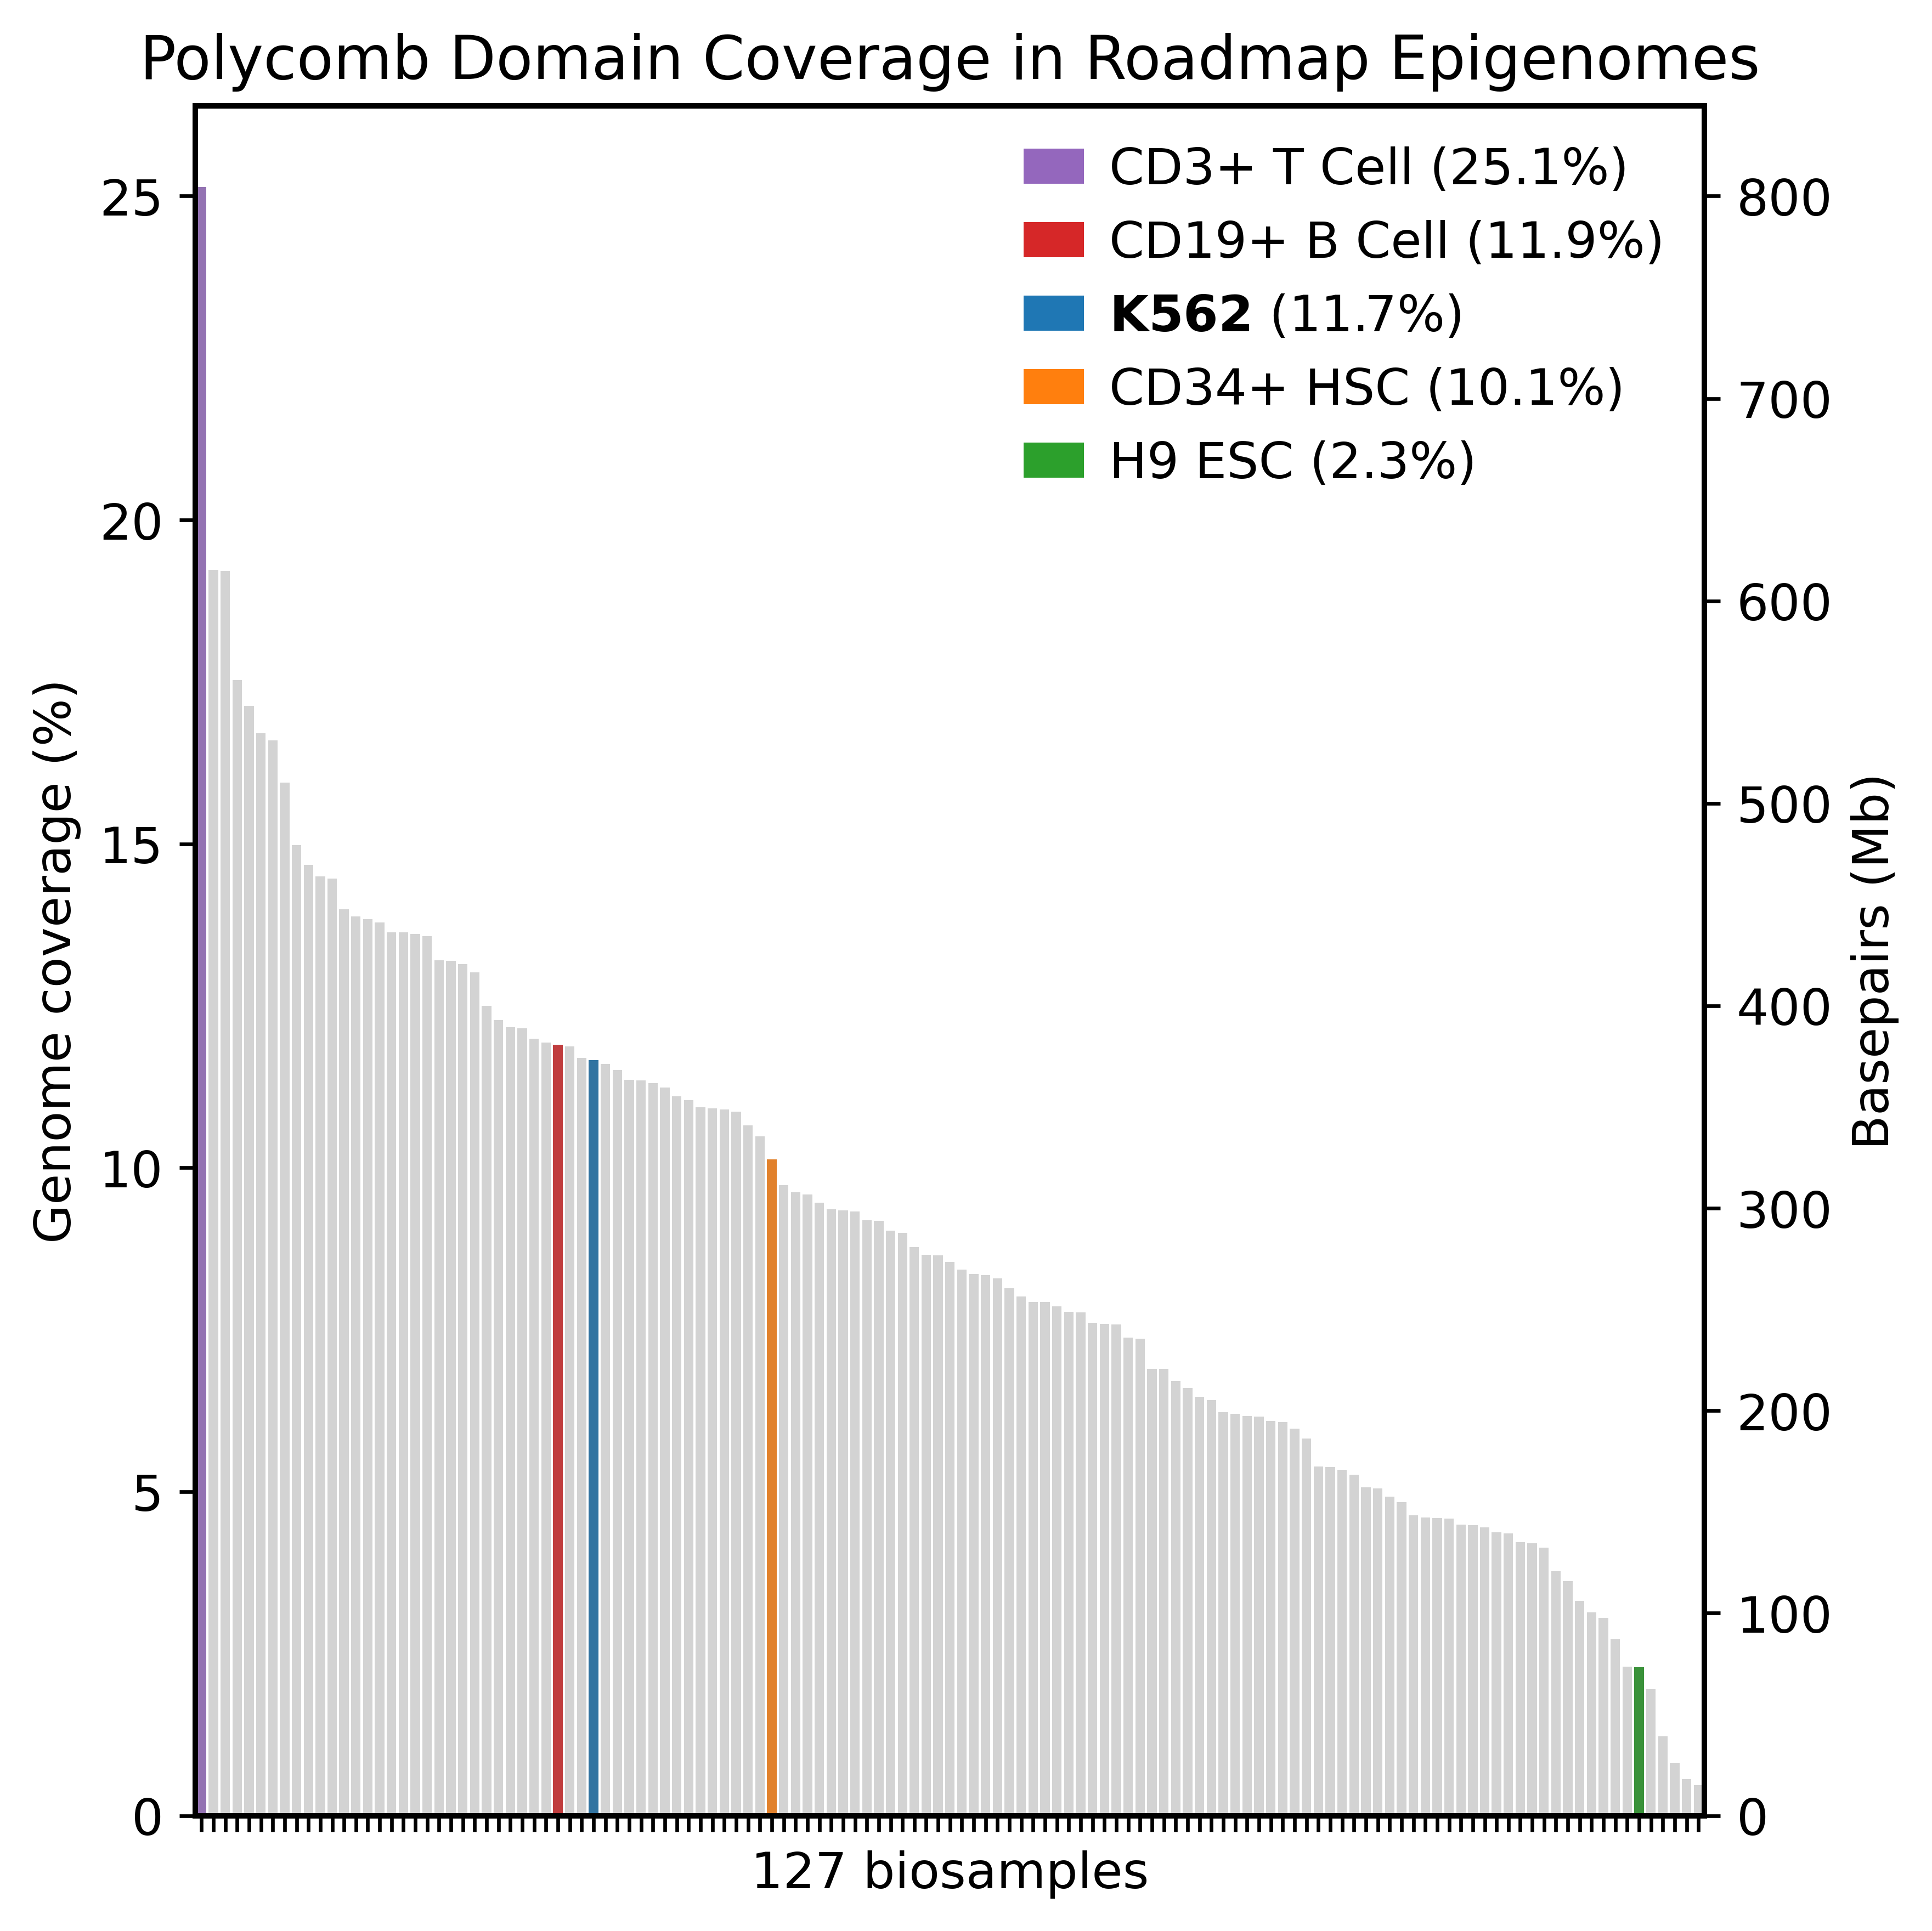

In [14]:
# ============================================================
# Inputs
# ============================================================
highlights = ["K562", "BLD.CD34.PC", "ESC.H9", "BLD.CD19.CPC", "BLD.CD3.PPC"]

display_label = {
    "K562": "K562",
    "BLD.CD34.PC": "CD34+ HSC",
    "ESC.H9": "H9 ESC",
    "BLD.CD19.CPC": "CD19+ B Cell",
    "BLD.CD3.PPC": "CD3+ T Cell",
}

# ============================================================
# Build plot_df
# ============================================================
plot_df = coverage_tbl.sort_values(by="polycomb_coverage_bp", ascending=False).copy()
plot_df["polycomb_coverage_mb"]  = plot_df["polycomb_coverage_bp"] / 1e6
plot_df["polycomb_coverage_per"] = plot_df["polycomb_coverage_bp"] / 3.2e9 * 100

plot_df = plot_df[plot_df["sample_id"].isin(meta["EID"])].copy()
plot_df = pd.concat(
    [plot_df.set_index("sample_id"), meta.set_index("EID")],
    axis=1, join="inner"
).reset_index(drop=False)

order = plot_df["filename"].drop_duplicates().tolist()

# ============================================================
# Highlight assignment (priority = highlights list order)
# ============================================================
mnem = plot_df["MNEMONIC"].astype(str)
plot_df["highlight"] = "Other"
for h in highlights:
    plot_df.loc[mnem.str.contains(h, na=False), "highlight"] = h

plot_df["highlight"] = pd.Categorical(
    plot_df["highlight"],
    categories=["Other"] + highlights,
    ordered=True
)

# ============================================================
# One representative per highlight for legend numbers:
# take the max coverage within each class (same as before)
# ============================================================
top_by_class = (
    plot_df.loc[plot_df["highlight"].isin(highlights), ["highlight", "filename", "polycomb_coverage_per"]]
    .sort_values(["highlight", "polycomb_coverage_per"], ascending=[True, False])
    .groupby("highlight", as_index=False)
    .head(1)
)
top_by_class["highlight"] = pd.Categorical(top_by_class["highlight"], categories=highlights, ordered=True)
top_by_class = top_by_class.sort_values("highlight").reset_index(drop=True)

# map highlight -> percent for legend
pct_map = dict(zip(top_by_class["highlight"].astype(str), top_by_class["polycomb_coverage_per"].values))

# ============================================================
# Plot
# ============================================================
pal = {"Other": "lightgray"}
pal.update(dict(zip(highlights, sns.color_palette("tab10", n_colors=len(highlights)).as_hex())))

fig, ax = plt.subplots(figsize=(6, 6), dpi=600)

sns.barplot(
    data=plot_df,
    x="filename",
    y="polycomb_coverage_per",
    order=order,
    hue="highlight",
    palette=pal,
    dodge=False,
    errorbar=None,
    ax=ax,
)

# remove seaborn legend (we will add a custom one)
leg = ax.get_legend()
if leg is not None:
    leg.remove()

ax.tick_params(axis="x", labelbottom=False)
ax.set_xlabel("127 biosamples")
ax.set_ylabel("Genome coverage (%)")
ax.set_title("Polycomb Domain Coverage in Roadmap Epigenomes")

# Right y-axis in Mb (Mb = % * 32)
ax2 = ax.twinx()
y0, y1 = ax.get_ylim()
ax2.set_ylim(y0 * 32, y1 * 32)
ax2.set_ylabel("Basepairs (Mb)")

# ============================================================
# Custom legend: color + cell type + percent; no frame; upper-right
# ============================================================
handles = []
labels = []
for h in highlights:
    pct = pct_map.get(h, np.nan)
    txt = f"{display_label[h]} ({pct:.1f}%)" if np.isfinite(pct) else f"{display_label[h]}"
    handles.append(Patch(facecolor=pal[h], edgecolor="none"))
    labels.append(txt)

from matplotlib.patches import Patch

# sort legend by percent (desc)
legend_df = (
    top_by_class[["highlight", "polycomb_coverage_per"]]
    .copy()
    .sort_values("polycomb_coverage_per", ascending=False)
)

handles, labels = [], []
for h, pct in zip(legend_df["highlight"].astype(str), legend_df["polycomb_coverage_per"].values):
    disp = display_label[h]
    # bold K562 in legend only
    if h == "K562":
        disp = rf"$\bf{{{disp}}}$"   # mathtext bold
    labels.append(f"{disp} ({pct:.1f}%)")
    handles.append(Patch(facecolor=pal[h], edgecolor="none"))

ax.legend(
    handles,
    labels,
    loc="upper right",
    frameon=False,
    borderaxespad=0.4,
    handlelength=1.2,
    handletextpad=0.5,
)


fig.savefig(os.path.join(FIG_DIR, "20260205_127_Roadmap_Domains.pdf"), bbox_inches="tight")

plt.tight_layout()


## Pairwise Jaccard similarity heatmap


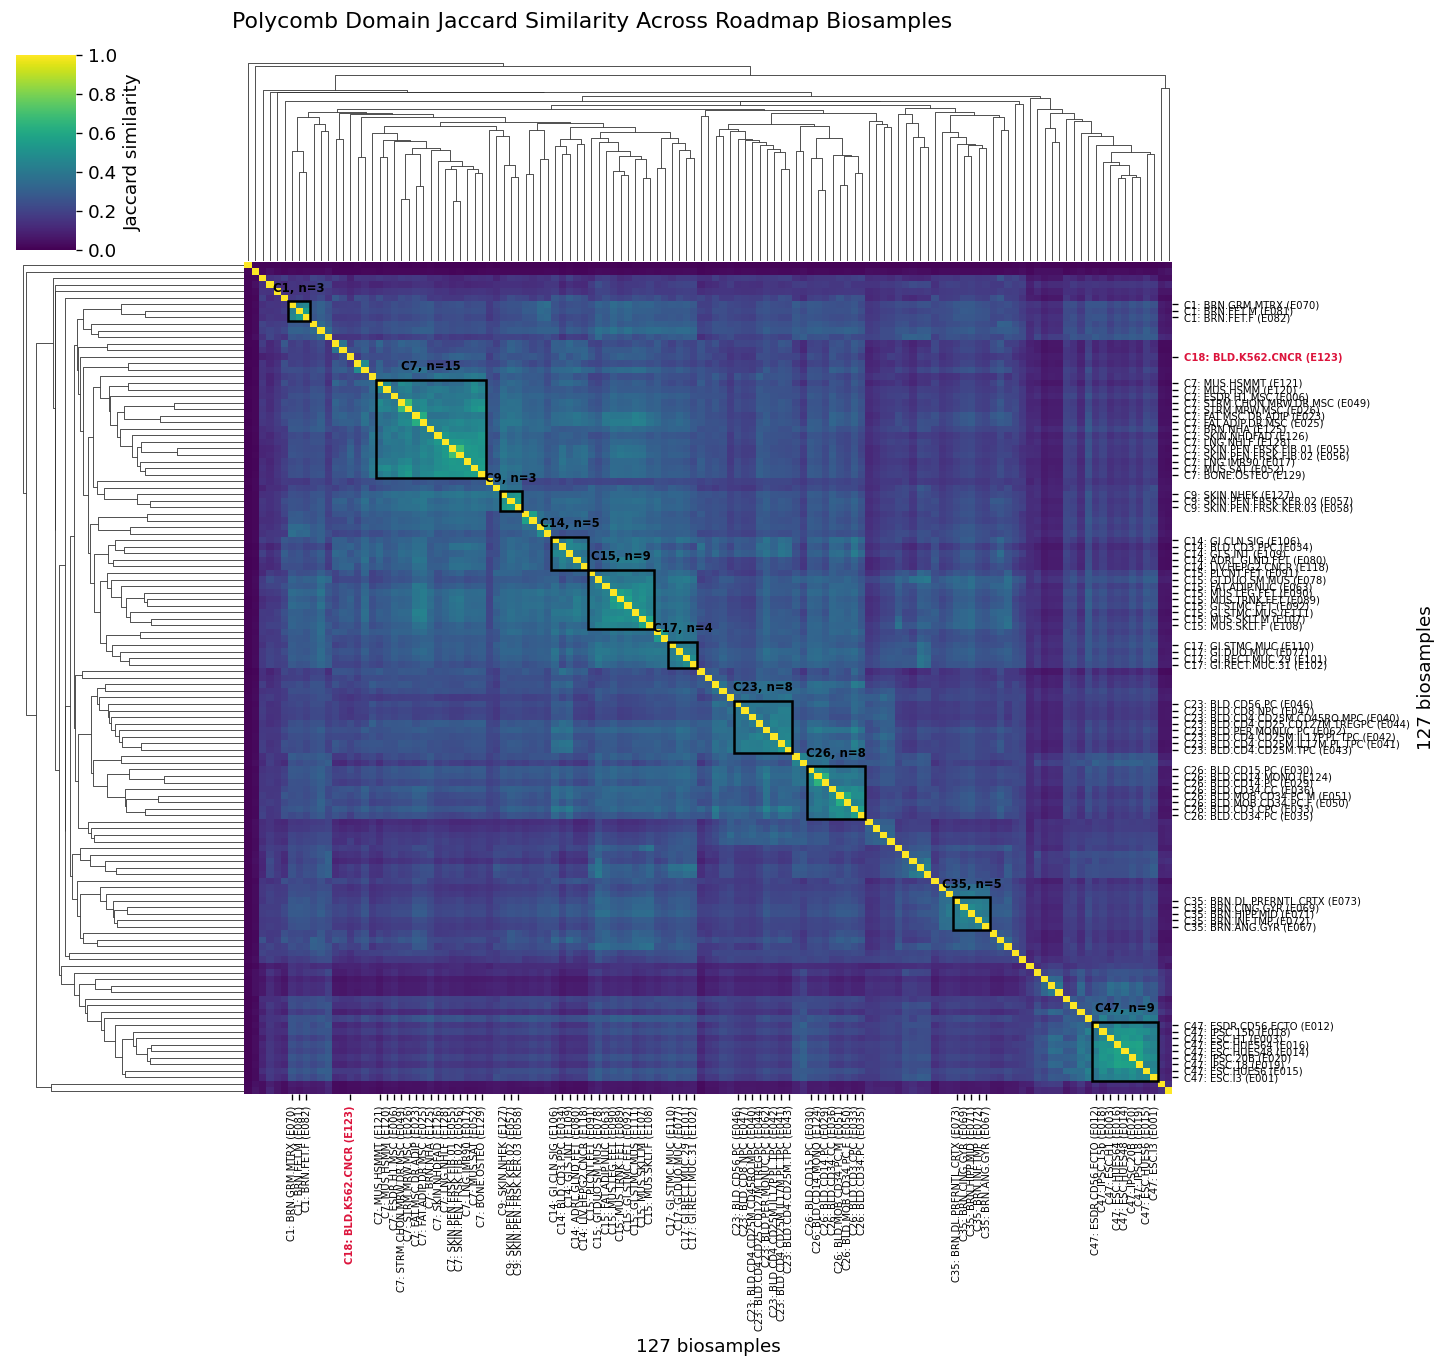

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# ------------------------------------------------------------
# Build clustered similarity matrix
# ------------------------------------------------------------
similarity_for_plot = jaccard_similarity.loc[
    summary_tbl["sample_id"],
    summary_tbl["sample_id"]
]

plot_matrix = similarity_for_plot.fillna(0.0)
np.fill_diagonal(plot_matrix.values, 1.0)

# Hierarchical clustering requires a distance, so cluster on 1 - similarity.
clustering_distance = 1.0 - plot_matrix
np.fill_diagonal(clustering_distance.values, 0.0)
condensed = squareform(clustering_distance.to_numpy(), checks=False)
cluster_linkage = linkage(condensed, method="average")

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
N_MAJOR_CLUSTERS = 60
TOP_N_CLUSTERS_TO_HIGHLIGHT = 10
MIN_CLUSTER_SIZE_TO_LABEL = 3
MAX_MEMBERS_TO_LABEL_PER_CLUSTER = 25

K562_COLOR = "crimson"
CLUSTER_BOX_COLOR = "black"

# ------------------------------------------------------------
# Assign major clusters
# ------------------------------------------------------------
cluster_ids = pd.Series(
    fcluster(cluster_linkage, t=N_MAJOR_CLUSTERS, criterion="maxclust"),
    index=plot_matrix.index,
    name="major_cluster",
)

metadata_by_sample = summary_tbl.set_index("sample_id")
mnemonic_by_sample = metadata_by_sample["MNEMONIC"].astype(str).to_dict()

# ------------------------------------------------------------
# Pick clusters to highlight
# ------------------------------------------------------------
cluster_sizes = cluster_ids.value_counts()
top_cluster_ids = cluster_sizes.head(TOP_N_CLUSTERS_TO_HIGHLIGHT).index.tolist()

k562_samples = [
    sample_id
    for sample_id in plot_matrix.index
    if "K562" in mnemonic_by_sample.get(sample_id, "")
]

k562_cluster_ids = cluster_ids.loc[k562_samples].unique().tolist()

clusters_to_highlight = []
for cluster_id in top_cluster_ids + k562_cluster_ids:
    if cluster_id not in clusters_to_highlight:
        clusters_to_highlight.append(cluster_id)

clusters_to_highlight = [
    cluster_id
    for cluster_id in clusters_to_highlight
    if (cluster_ids == cluster_id).sum() >= MIN_CLUSTER_SIZE_TO_LABEL
]

# ------------------------------------------------------------
# Define sample labels
# ------------------------------------------------------------
label_samples = set()

# Always label K562 and reference
label_samples.add(REFERENCE_SAMPLE_ID)
label_samples.update(k562_samples)

# Label members of highlighted clusters
for cluster_id in clusters_to_highlight:
    cluster_samples = cluster_ids.index[cluster_ids == cluster_id].tolist()

    # Keep plot readable for very large clusters by labeling the most central samples.
    if len(cluster_samples) > MAX_MEMBERS_TO_LABEL_PER_CLUSTER:
        within_cluster = plot_matrix.loc[cluster_samples, cluster_samples]
        mean_similarity = within_cluster.mean(axis=1)
        cluster_samples_to_label = (
            mean_similarity
            .sort_values(ascending=False)
            .head(MAX_MEMBERS_TO_LABEL_PER_CLUSTER)
            .index
            .tolist()
        )
    else:
        cluster_samples_to_label = cluster_samples

    label_samples.update(cluster_samples_to_label)

label_text = {}

for sample_id in label_samples:
    if sample_id not in plot_matrix.index:
        continue

    cluster_id = cluster_ids.loc[sample_id]
    mnemonic = mnemonic_by_sample.get(sample_id, sample_id)

    label_text[sample_id] = f"C{cluster_id}: {mnemonic} ({sample_id})"

# ------------------------------------------------------------
# Plot clustermap
# ------------------------------------------------------------
cg = sns.clustermap(
    plot_matrix,
    row_linkage=cluster_linkage,
    col_linkage=cluster_linkage,
    cmap="viridis",
    vmin=0,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    figsize=(10, 9),
    cbar_kws={"label": "Jaccard similarity"},
)

# ------------------------------------------------------------
# Get clustered order
# ------------------------------------------------------------
row_order = [plot_matrix.index[i] for i in cg.dendrogram_row.reordered_ind]
col_order = [plot_matrix.columns[i] for i in cg.dendrogram_col.reordered_ind]

row_index_by_sample = {
    sample_id: i
    for i, sample_id in enumerate(row_order)
}

col_index_by_sample = {
    sample_id: i
    for i, sample_id in enumerate(col_order)
}

# ------------------------------------------------------------
# Add axis labels for selected samples
# ------------------------------------------------------------
row_positions = [
    row_index_by_sample[sample_id] + 0.5
    for sample_id in row_order
    if sample_id in label_text
]

row_labels = [
    label_text[sample_id]
    for sample_id in row_order
    if sample_id in label_text
]

col_positions = [
    col_index_by_sample[sample_id] + 0.5
    for sample_id in col_order
    if sample_id in label_text
]

col_labels = [
    label_text[sample_id]
    for sample_id in col_order
    if sample_id in label_text
]

cg.ax_heatmap.set_yticks(row_positions)
cg.ax_heatmap.set_yticklabels(row_labels, rotation=0, fontsize=6)

cg.ax_heatmap.set_xticks(col_positions)
cg.ax_heatmap.set_xticklabels(col_labels, rotation=90, fontsize=6)

# Bold K562 and reference labels
for tick in list(cg.ax_heatmap.get_yticklabels()) + list(cg.ax_heatmap.get_xticklabels()):
    tick_text = tick.get_text()

    if "K562" in tick_text or f"({REFERENCE_SAMPLE_ID})" in tick_text:
        tick.set_fontweight("bold")
        tick.set_color(K562_COLOR)

# ------------------------------------------------------------
# Draw boxes around highlighted clusters
# ------------------------------------------------------------
for cluster_id in clusters_to_highlight:
    cluster_samples = cluster_ids.index[cluster_ids == cluster_id].tolist()

    row_positions_cluster = [
        row_index_by_sample[sample_id]
        for sample_id in cluster_samples
        if sample_id in row_index_by_sample
    ]

    col_positions_cluster = [
        col_index_by_sample[sample_id]
        for sample_id in cluster_samples
        if sample_id in col_index_by_sample
    ]

    if len(row_positions_cluster) == 0 or len(col_positions_cluster) == 0:
        continue

    row_min = min(row_positions_cluster)
    row_max = max(row_positions_cluster)
    col_min = min(col_positions_cluster)
    col_max = max(col_positions_cluster)

    box_width = col_max - col_min + 1
    box_height = row_max - row_min + 1

    contains_k562 = any(sample_id in k562_samples for sample_id in cluster_samples)

    box_color = K562_COLOR if contains_k562 else CLUSTER_BOX_COLOR
    box_linewidth = 2.0 if contains_k562 else 1.5

    cg.ax_heatmap.add_patch(
        patches.Rectangle(
            (col_min, row_min),
            box_width,
            box_height,
            fill=False,
            edgecolor=box_color,
            linewidth=box_linewidth,
            clip_on=False,
        )
    )

    cluster_label = f"C{cluster_id}, n={len(cluster_samples)}"

    cg.ax_heatmap.text(
        col_min + box_width / 2,
        row_min - 1.0,
        cluster_label,
        ha="center",
        va="bottom",
        fontsize=7,
        fontweight="bold",
        color=box_color,
        clip_on=False,
    )

# ------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------
cg.ax_heatmap.set_xlabel(f"{similarity_for_plot.shape[0]} biosamples")
cg.ax_heatmap.set_ylabel(f"{similarity_for_plot.shape[0]} biosamples")

cg.fig.suptitle(
    "Polycomb Domain Jaccard Similarity Across Roadmap Biosamples",
    y=1.02,
)

cg.fig.savefig(
    FIG_DIR / "20260205_127_Roadmap_Domain_Jaccard_Similarity_Heatmap.pdf",
    bbox_inches="tight",
)


## Reciprocal overlap fraction heatmap

Reciprocal overlap fraction measures how much of one biosample's domain bases are covered by another biosample's domains. For each pair, this section computes both directional values, `A covered by B` and `B covered by A`, then uses their mean as a symmetric matrix for clustering and heatmap visualization. A value of 1 means complete reciprocal coverage, and 0 means no overlapping domain bases.


In [17]:
def _domain_bp_by_sample(all_domains: pd.DataFrame, sample_col: str = "sample_id") -> pd.Series:
    domains = all_domains.copy()
    domains[sample_col] = domains[sample_col].astype(str)
    return (
        domains.assign(length_bp=domains["end"] - domains["start"])
        .groupby(sample_col)["length_bp"]
        .sum()
        .astype(float)
    )


def pairwise_reciprocal_overlap_fraction(
    all_domains: pd.DataFrame,
    sample_col: str = "sample_id",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    domains = all_domains.copy()
    domains[sample_col] = domains[sample_col].astype(str)
    samples = sorted(domains[sample_col].dropna().unique())
    domain_bp = _domain_bp_by_sample(domains, sample_col=sample_col).reindex(samples)

    bedtools_by_sample = {
        sample: _make_bedtool(domains.loc[domains[sample_col] == sample, ["chrom", "start", "end"]])
        for sample in samples
    }

    a_covered_by_b = pd.DataFrame(np.nan, index=samples, columns=samples, dtype=float)
    b_covered_by_a = pd.DataFrame(np.nan, index=samples, columns=samples, dtype=float)
    mean_reciprocal_overlap = pd.DataFrame(np.nan, index=samples, columns=samples, dtype=float)

    for i, sample_a in enumerate(tqdm(samples, desc="Reciprocal overlap fraction")):
        a_covered_by_b.iat[i, i] = 1.0
        b_covered_by_a.iat[i, i] = 1.0
        mean_reciprocal_overlap.iat[i, i] = 1.0

        for j in range(i + 1, len(samples)):
            sample_b = samples[j]
            stats = bedtools_by_sample[sample_a].jaccard(b=bedtools_by_sample[sample_b])
            intersection_bp = float(stats["intersection"])

            a_fraction = intersection_bp / domain_bp.loc[sample_a] if domain_bp.loc[sample_a] > 0 else np.nan
            b_fraction = intersection_bp / domain_bp.loc[sample_b] if domain_bp.loc[sample_b] > 0 else np.nan
            mean_fraction = np.nanmean([a_fraction, b_fraction])

            a_covered_by_b.iat[i, j] = a_fraction
            a_covered_by_b.iat[j, i] = b_fraction
            b_covered_by_a.iat[i, j] = b_fraction
            b_covered_by_a.iat[j, i] = a_fraction
            mean_reciprocal_overlap.iat[i, j] = mean_fraction
            mean_reciprocal_overlap.iat[j, i] = mean_fraction

    return a_covered_by_b, b_covered_by_a, mean_reciprocal_overlap


rof_a_covered_by_b, rof_b_covered_by_a, mean_reciprocal_overlap = pairwise_reciprocal_overlap_fraction(all_domains)

rof_off_diagonal = mean_reciprocal_overlap.copy()
np.fill_diagonal(rof_off_diagonal.values, np.nan)
coverage_tbl["mean_reciprocal_overlap_fraction"] = coverage_tbl["sample_id"].astype(str).map(rof_off_diagonal.mean(axis=1))
coverage_tbl["median_reciprocal_overlap_fraction"] = coverage_tbl["sample_id"].astype(str).map(rof_off_diagonal.median(axis=1))
coverage_tbl["most_reciprocally_overlapping_sample_id"] = coverage_tbl["sample_id"].astype(str).map(rof_off_diagonal.idxmax(axis=1))
coverage_tbl["most_reciprocal_overlap_fraction"] = coverage_tbl["sample_id"].astype(str).map(rof_off_diagonal.max(axis=1))

if REFERENCE_SAMPLE_ID in mean_reciprocal_overlap.index:
    coverage_tbl[f"mean_reciprocal_overlap_to_{REFERENCE_SAMPLE_ID}"] = (
        coverage_tbl["sample_id"].astype(str).map(mean_reciprocal_overlap[REFERENCE_SAMPLE_ID])
    )

summary_tbl = (
    coverage_tbl[coverage_tbl["sample_id"].isin(meta["EID"])]
    .merge(meta, left_on="sample_id", right_on="EID", how="left")
    .sort_values("polycomb_coverage_bp", ascending=False)
    .reset_index(drop=True)
)

summary_tbl[[
    "sample_id",
    "MNEMONIC",
    "mean_reciprocal_overlap_fraction",
    "median_reciprocal_overlap_fraction",
    "most_reciprocally_overlapping_sample_id",
    "most_reciprocal_overlap_fraction",
    f"mean_reciprocal_overlap_to_{REFERENCE_SAMPLE_ID}",
]].head(10)


Reciprocal overlap fraction: 100%|██████████| 127/127 [03:52<00:00,  1.83s/it]


,sample_id,MNEMONIC,mean_reciprocal_overlap_fraction,median_reciprocal_overlap_fraction,most_reciprocally_overlapping_sample_id,most_reciprocal_overlap_fraction,mean_reciprocal_overlap_to_E123
0,E034,BLD.CD3.PPC,0.518109,0.532753,E109,0.653988,0.557165
1,E080,ADRL.GLND.FET,0.473716,0.482703,E092,0.629541,0.483147
2,E121,MUS.HSMMT,0.431033,0.424638,E120,0.692713,0.397005
3,E109,GI.S.INT,0.489188,0.497876,E034,0.653988,0.434912
4,E118,LIV.HEPG2.CNCR,0.445100,0.443157,E034,0.614499,0.511351
5,E061,SKIN.PEN.FRSK.MEL.03,0.380100,0.386233,E059,0.652317,0.307792
6,E017,LNG.IMR90,0.445470,0.432808,E128,0.712997,0.472854
7,E115,BLD.DND41.CNCR,0.380808,0.396286,E034,0.575153,0.411573
8,E049,STRM.CHON.MRW.DR.MSC,0.441549,0.433033,E026,0.815533,0.406424
9,E052,MUS.SAT,0.447227,0.431711,E129,0.717610,0.453828


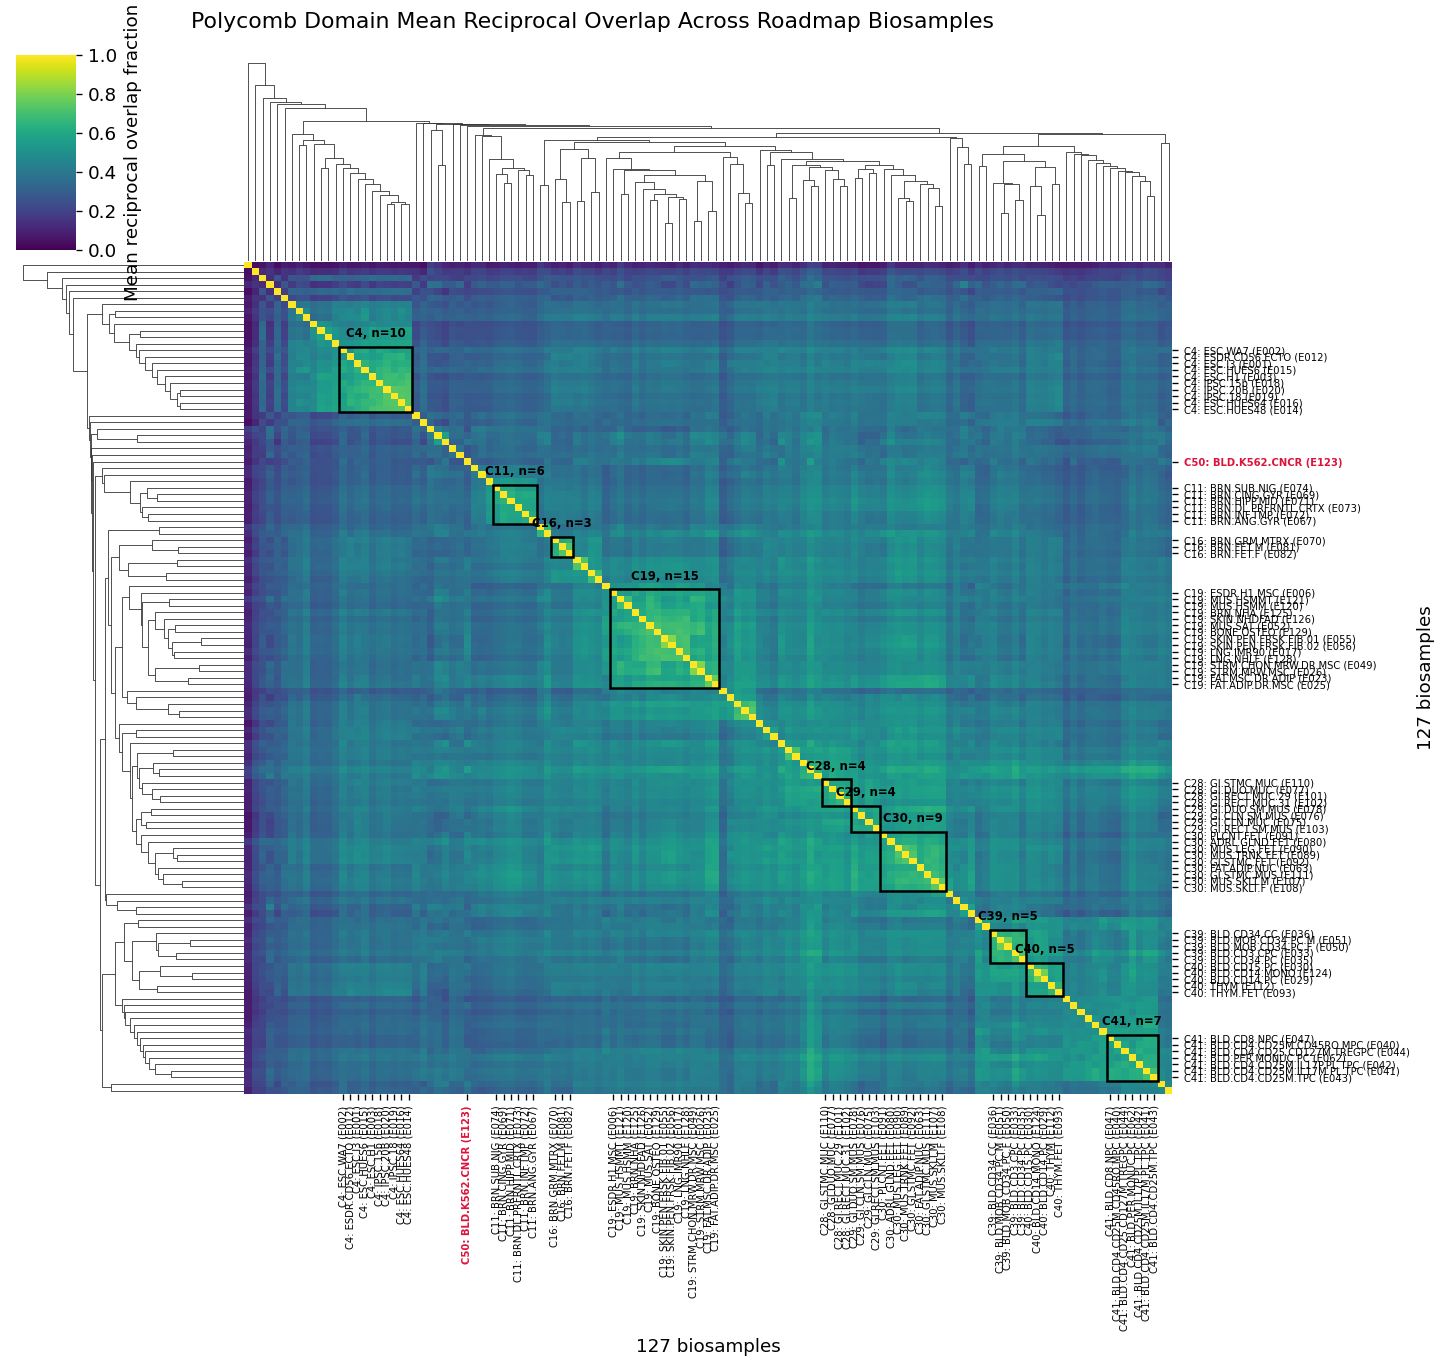

In [18]:
rof_for_plot = mean_reciprocal_overlap.loc[
    summary_tbl["sample_id"],
    summary_tbl["sample_id"]
]

rof_plot_matrix = rof_for_plot.fillna(0.0)
np.fill_diagonal(rof_plot_matrix.values, 1.0)

rof_clustering_distance = 1.0 - rof_plot_matrix
np.fill_diagonal(rof_clustering_distance.values, 0.0)
rof_condensed = squareform(rof_clustering_distance.to_numpy(), checks=False)
rof_cluster_linkage = linkage(rof_condensed, method="average")

N_MAJOR_CLUSTERS = 60
TOP_N_CLUSTERS_TO_HIGHLIGHT = 10
MIN_CLUSTER_SIZE_TO_LABEL = 3
MAX_MEMBERS_TO_LABEL_PER_CLUSTER = 25

K562_COLOR = "crimson"
CLUSTER_BOX_COLOR = "black"

rof_cluster_ids = pd.Series(
    fcluster(rof_cluster_linkage, t=N_MAJOR_CLUSTERS, criterion="maxclust"),
    index=rof_plot_matrix.index,
    name="major_cluster",
)

metadata_by_sample = summary_tbl.set_index("sample_id")
mnemonic_by_sample = metadata_by_sample["MNEMONIC"].astype(str).to_dict()
cluster_sizes = rof_cluster_ids.value_counts()
top_cluster_ids = cluster_sizes.head(TOP_N_CLUSTERS_TO_HIGHLIGHT).index.tolist()

k562_samples = [
    sample_id
    for sample_id in rof_plot_matrix.index
    if "K562" in mnemonic_by_sample.get(sample_id, "")
]
k562_cluster_ids = rof_cluster_ids.loc[k562_samples].unique().tolist()

clusters_to_highlight = []
for cluster_id in top_cluster_ids + k562_cluster_ids:
    if cluster_id not in clusters_to_highlight:
        clusters_to_highlight.append(cluster_id)

clusters_to_highlight = [
    cluster_id
    for cluster_id in clusters_to_highlight
    if (rof_cluster_ids == cluster_id).sum() >= MIN_CLUSTER_SIZE_TO_LABEL
]

label_samples = {REFERENCE_SAMPLE_ID}
label_samples.update(k562_samples)

for cluster_id in clusters_to_highlight:
    cluster_samples = rof_cluster_ids.index[rof_cluster_ids == cluster_id].tolist()
    if len(cluster_samples) > MAX_MEMBERS_TO_LABEL_PER_CLUSTER:
        within_cluster = rof_plot_matrix.loc[cluster_samples, cluster_samples]
        mean_overlap = within_cluster.mean(axis=1)
        cluster_samples_to_label = (
            mean_overlap
            .sort_values(ascending=False)
            .head(MAX_MEMBERS_TO_LABEL_PER_CLUSTER)
            .index
            .tolist()
        )
    else:
        cluster_samples_to_label = cluster_samples

    label_samples.update(cluster_samples_to_label)

label_text = {}
for sample_id in label_samples:
    if sample_id not in rof_plot_matrix.index:
        continue
    cluster_id = rof_cluster_ids.loc[sample_id]
    mnemonic = mnemonic_by_sample.get(sample_id, sample_id)
    label_text[sample_id] = f"C{cluster_id}: {mnemonic} ({sample_id})"

cg = sns.clustermap(
    rof_plot_matrix,
    row_linkage=rof_cluster_linkage,
    col_linkage=rof_cluster_linkage,
    cmap="viridis",
    vmin=0,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    figsize=(10, 9),
    cbar_kws={"label": "Mean reciprocal overlap fraction"},
)

row_order = [rof_plot_matrix.index[i] for i in cg.dendrogram_row.reordered_ind]
col_order = [rof_plot_matrix.columns[i] for i in cg.dendrogram_col.reordered_ind]
row_index_by_sample = {sample_id: i for i, sample_id in enumerate(row_order)}
col_index_by_sample = {sample_id: i for i, sample_id in enumerate(col_order)}

row_positions = [row_index_by_sample[sample_id] + 0.5 for sample_id in row_order if sample_id in label_text]
row_labels = [label_text[sample_id] for sample_id in row_order if sample_id in label_text]
col_positions = [col_index_by_sample[sample_id] + 0.5 for sample_id in col_order if sample_id in label_text]
col_labels = [label_text[sample_id] for sample_id in col_order if sample_id in label_text]

cg.ax_heatmap.set_yticks(row_positions)
cg.ax_heatmap.set_yticklabels(row_labels, rotation=0, fontsize=6)
cg.ax_heatmap.set_xticks(col_positions)
cg.ax_heatmap.set_xticklabels(col_labels, rotation=90, fontsize=6)

for tick in list(cg.ax_heatmap.get_yticklabels()) + list(cg.ax_heatmap.get_xticklabels()):
    tick_text = tick.get_text()
    if "K562" in tick_text or f"({REFERENCE_SAMPLE_ID})" in tick_text:
        tick.set_fontweight("bold")
        tick.set_color(K562_COLOR)

for cluster_id in clusters_to_highlight:
    cluster_samples = rof_cluster_ids.index[rof_cluster_ids == cluster_id].tolist()
    row_positions_cluster = [row_index_by_sample[sample_id] for sample_id in cluster_samples if sample_id in row_index_by_sample]
    col_positions_cluster = [col_index_by_sample[sample_id] for sample_id in cluster_samples if sample_id in col_index_by_sample]

    if len(row_positions_cluster) == 0 or len(col_positions_cluster) == 0:
        continue

    row_min = min(row_positions_cluster)
    row_max = max(row_positions_cluster)
    col_min = min(col_positions_cluster)
    col_max = max(col_positions_cluster)
    box_width = col_max - col_min + 1
    box_height = row_max - row_min + 1
    contains_k562 = any(sample_id in k562_samples for sample_id in cluster_samples)
    box_color = K562_COLOR if contains_k562 else CLUSTER_BOX_COLOR
    box_linewidth = 2.0 if contains_k562 else 1.5

    cg.ax_heatmap.add_patch(
        patches.Rectangle(
            (col_min, row_min),
            box_width,
            box_height,
            fill=False,
            edgecolor=box_color,
            linewidth=box_linewidth,
            clip_on=False,
        )
    )

    cg.ax_heatmap.text(
        col_min + box_width / 2,
        row_min - 1.0,
        f"C{cluster_id}, n={len(cluster_samples)}",
        ha="center",
        va="bottom",
        fontsize=7,
        fontweight="bold",
        color=box_color,
        clip_on=False,
    )

cg.ax_heatmap.set_xlabel(f"{rof_for_plot.shape[0]} biosamples")
cg.ax_heatmap.set_ylabel(f"{rof_for_plot.shape[0]} biosamples")
cg.fig.suptitle(
    "Polycomb Domain Mean Reciprocal Overlap Across Roadmap Biosamples",
    y=1.02,
)
cg.fig.savefig(
    FIG_DIR / "20260205_127_Roadmap_Domain_Reciprocal_Overlap_Heatmap.pdf",
    bbox_inches="tight",
)
